# Object Detection with YOLOXTrainer

This notebook shows how to train an **YOLOX object detection** model on the **BCCD** (Blood Cell Count and Detection) dataset using Datamint's **Trainer API**.

## About YOLOX

YOLOX is an anchor-free, single-stage object detector that simplifies the YOLO pipeline by removing the need to pre-define anchor boxes. It comes in six size variants — `nano`, `tiny`, `s`, `m`, `l`, `x` — so you can trade speed for accuracy with a single parameter.

> Ge, Z., Liu, S., Wang, F., Li, Z., & Sun, J. (2021). YOLOX: Exceeding YOLO Series in 2021. *arXiv preprint arXiv:2107.08430.*

## What You'll Learn

1. Upload images and bounding box annotations to Datamint
2. Train a YOLOX detection model with **one line of code**
3. Visualize predictions locally
4. Deploy the trained model to the Datamint server and run remote inference

## Required Dependencies

```bash
pip install datamint[detection] "torchmetrics[detection]>=1.0"
```

In [1]:
from datamint import Api

PROJECT_NAME = "bccd_detection"
api = Api()

/home/luan/Desktop/Datamint/Codes/datamint-python-api/datamint/env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Setup: Create Project and Load Dataset

`datamint.examples.bccd_dataset` downloads the [BCCD dataset](https://github.com/Shenggan/BCCD_Dataset), parses its Pascal VOC bounding-box annotations, and uploads everything to a Datamint project: 364 microscopy images across three classes (`RBC`, `WBC`, `Platelets`). The dataset is cached locally after the first download, and the call is idempotent, if the project already exists, it's returned as-is without re-uploading.

In [ ]:
from datamint.examples import bccd_dataset

proj = bccd_dataset.create(project_name=PROJECT_NAME)
proj

## 2. Training with YOLOXTrainer

This is where the **Trainer API** shines. Instead of manually defining:
- A detection dataset with the correct annotation parsing
- A variable-length collate function for bounding boxes
- A LightningModule wiring YOLOX's internal loss and NMS
- Callbacks, loggers, and a Lightning Trainer
- A deployment adapter

...you simply create a `YOLOXTrainer` and call `fit()`.

The trainer automatically:
1. Builds a `DetectionDataset` from the Datamint project
2. Constructs a stable class map from annotation identifiers, sorted alphabetically
3. Creates bbox-aware augmentation pipelines (resize, flip, color jitter, normalize)
4. Instantiates a `YOLOXModule` wrapping the chosen YOLOX variant
5. Configures MLflow logging, checkpointing on `val/map`, and early stopping
6. Trains, evaluates on the test split, and **registers the best checkpoint** in the MLflow Model Registry

| Index | Class |
|-------|-------|
| 0 | Platelets |
| 1 | RBC |
| 2 | WBC |

In [3]:
import random

all_resources = list(api.resources.get_list(project_name=PROJECT_NAME))
all_resources.sort(key=lambda r: r.filename)

random.seed(42)
random.shuffle(all_resources)

n_total = len(all_resources)
n_train = int(0.7 * n_total)
n_val = int(0.15 * n_total)

train_resources = all_resources[:n_train]
val_resources = all_resources[n_train:n_train + n_val]
test_resources = all_resources[n_train + n_val:]

api.projects.assign_splits(train_resources, split_name='train', project=proj)
api.projects.assign_splits(val_resources, split_name='val', project=proj)
api.projects.assign_splits(test_resources, split_name='test', project=proj)

print(f"Train: {len(train_resources)}, Val: {len(val_resources)}, Test: {len(test_resources)}")

Train: 254, Val: 54, Test: 56


In [ ]:

from datamint.lightning import YOLOXTrainer

trainer = YOLOXTrainer(
    project=PROJECT_NAME,
    model_size="s",    # nano / tiny / s / m / l / x
    image_size=416,
    batch_size=8,
    max_epochs=10,
    early_stopping_patience=10,
    accelerator="auto",
)

results = trainer.fit()

In [5]:
# Class map built from annotations — needed to convert prediction indices back to names
class_map     = trainer.dataset.box_class_map            # {'Platelets': 0, 'RBC': 1, 'WBC': 2}
inv_class_map = {v: k for k, v in class_map.items()}  # {0: 'Platelets', 1: 'RBC', 2: 'WBC'}

print("Class map:   ", class_map)
print("Test metrics:", results["test_results"])

Class map:    {'Platelets': 0, 'RBC': 1, 'WBC': 2}
Test metrics: [{'test/map': 0.4984062910079956}]


## Inspect the Registered Model

Training automatically registered the model in Datamint's model registry (backed by MLflow).
Use `api.models` to inspect it without touching MLflow's client directly:

In [ ]:
registered_model = api.models.get_by_name(PROJECT_NAME)
latest_version = registered_model.get_latest_version()

print(f"Version: {latest_version.version}")
print(f"Task type: {latest_version.get_task_type()}")
print(f"Supported modes: {latest_version.get_supported_modes()}")
print("Metrics:")
for metric_name, value in latest_version.get_metrics().items():
    print(f"  {metric_name}: {value}")

## 3. Visualize Predictions

Let's visualize the model predictions against ground truth on test samples.

/home/luan/Desktop/Datamint/Codes/datamint-python-api/datamint/env/lib/python3.12/site-packages/albumentations/core/transforms_interface.py:310: UserWarning: The image is already an RGB.
  target_function(ensure_contiguous_output(arg), **params),


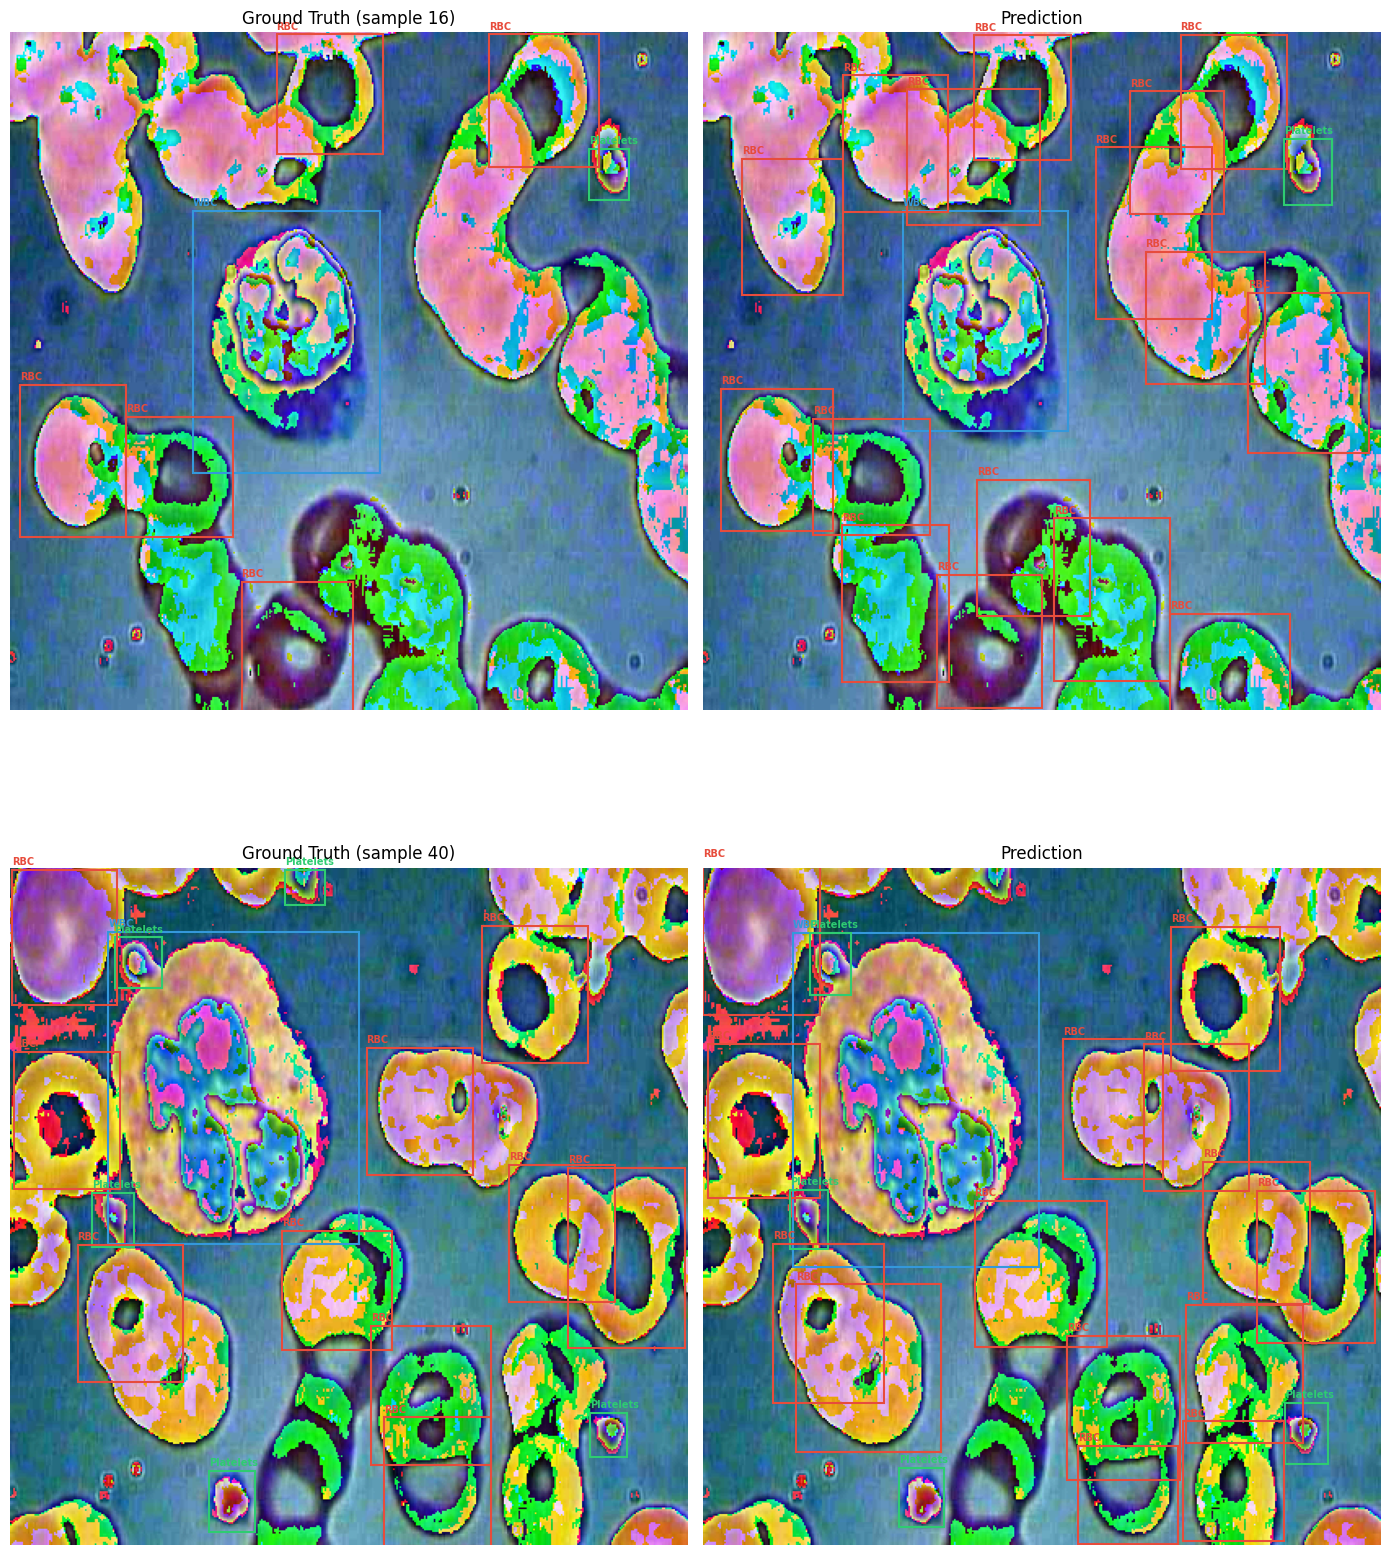

In [6]:
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import numpy as np
import torch
from yolox.utils import postprocess

COLORS = {"RBC": "#e74c3c", "WBC": "#3498db", "Platelets": "#2ecc71"}

model = trainer.model
model.eval()

test_dataset = trainer.datamodule.test_dataloader().dataset

fig, axes = plt.subplots(2, 2, figsize=(14, 18))

for row in range(2):
    idx = np.random.randint(len(test_dataset))
    sample = test_dataset[idx]
    image  = sample["image"]   # (C, H, W) tensor
    gt_boxes  = sample["boxes"]   # (N, 4) pascal_voc
    gt_labels = sample["box_labels"]  # (N,)

    with torch.inference_mode():
        raw  = model.model(image.unsqueeze(0).to(model.device))
        preds = postprocess(raw, model.hparams["num_classes"],
                            model.hparams["conf_thre"], model.hparams["nms_thre"])

    img_np = (image.permute(1, 2, 0).cpu().numpy() * 255).astype(np.uint8)

    # Ground truth
    ax = axes[row, 0]
    ax.imshow(img_np)
    for box, lbl in zip(gt_boxes, gt_labels):
        cls_name = inv_class_map.get(int(lbl), str(int(lbl)))
        color = COLORS.get(cls_name, "white")
        x1, y1, x2, y2 = box.tolist()
        ax.add_patch(mpatches.Rectangle((x1, y1), x2 - x1, y2 - y1,
                                         linewidth=1.5, edgecolor=color, facecolor="none"))
        ax.text(x1, y1 - 3, cls_name, color=color, fontsize=7, fontweight="bold")
    ax.set_title(f"Ground Truth (sample {idx})")
    ax.axis("off")

    # Prediction
    ax = axes[row, 1]
    ax.imshow(img_np)
    if preds[0] is not None:
        for det in preds[0].cpu():
            x1, y1, x2, y2 = det[:4].tolist()
            cls_name = inv_class_map.get(int(det[6]), str(int(det[6])))
            color = COLORS.get(cls_name, "white")
            ax.add_patch(mpatches.Rectangle((x1, y1), x2 - x1, y2 - y1,
                                             linewidth=1.5, edgecolor=color, facecolor="none"))
            ax.text(x1, y1 - 3, cls_name, color=color, fontsize=7, fontweight="bold")
    ax.set_title("Prediction")
    ax.axis("off")

plt.tight_layout()
plt.show()

## 4. Deployment

The trainer **automatically** registered a deployment-ready model in MLflow after training.
You can deploy it directly to the Datamint server:

In [15]:
job = api.deploy.start(
    model_name=PROJECT_NAME,
    model_alias="latest",
    with_gpu=False,
)

print("Deployment job started!")
print(f"Job ID: {job.id}")
print(f"Status: {job.status}")

Deployment job started!
Job ID: 3c452320-cc89-4f4c-98d5-cd3c4b7ee6b8
Status: running


In [16]:
job = api.deploy.get_by_id(job.id)

print(f"Job Status: {job.status}")
print(f"Progress:   {job.progress_percentage}%")

if job.error_message:
    print(f"Error: {job.error_message}")

Job Status: running
Progress:   50%


`Model.is_deployed()` reports the same thing, without tracking job IDs, once the job above reaches `completed`.

In [ ]:
registered_model.is_deployed()

### 4.1 Remote Inference

In [ ]:
r = api.resources.get_list(project_name=PROJECT_NAME, limit=1)[0]

inf_job = api.inference.submit(
    model_name=PROJECT_NAME,
    model_alias="latest",
    resource_id=r.id,
)
inf_job.wait()

In [ ]:
preds = inf_job.predictions[0]  # list[BoxAnnotation] for the first resource

img_np = np.array(r.fetch_file_data(auto_convert=True, use_cache=True))

fig, ax = plt.subplots(figsize=(8, 6))
ax.imshow(img_np)
for box in preds:
    cls_name = inv_class_map.get(int(box.identifier), box.identifier)
    x1, y1, _ = box.geometry.point1
    x2, y2, _ = box.geometry.point2
    color = COLORS.get(cls_name, "white")
    ax.add_patch(mpatches.Rectangle(
        (x1, y1), x2 - x1, y2 - y1,
        linewidth=2, edgecolor=color, facecolor="none",
    ))
    ax.text(x1, y1 - 4, cls_name, color=color, fontsize=8, fontweight="bold")
ax.axis("off")
ax.set_title(getattr(r, "name", str(r.id)))
plt.tight_layout()
plt.show()

In [ ]:
proj.show()

## Summary: What the Trainer API Automates

The Trainer API automatically handles the full detection workflow, including:

- Dataset loading and box annotation parsing
- Variable-length collate function for bounding boxes
- Bbox-aware augmentation pipelines (resize, flip, color jitter, normalize)
- Stable class map construction from annotation identifiers
- YOLOX model instantiation (anchor-free, internal loss)
- Mean Average Precision metric configuration
- Lightning Trainer setup with early stopping on `val/map`
- MLflow experiment tracking and checkpoint registration
- Test-time evaluation
- Deployment-ready model artifact
